<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/RandomForestMachineLearAlgo(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classifier & Regressor

A **Random Forest** is an ensemble machine learning algorithm used for both classification and regression tasks. Instead of relying on a single decision maker, it builds a "forest" of independent decision trees and combines their outputs to make a more accurate and stable prediction.

> **Analogy:** Think of it like a panel of experts. Instead of asking one doctor for a medical diagnosis, you ask a diverse group of doctors and take a majority vote.



## 1. Why and When We Use It

* **Why:** Single decision trees are highly prone to overfitting (they memorize the training data noise). Random Forest fixes this by averaging multiple trees, which cancels out individual errors, lowers model variance, and dramatically increases accuracy.
* **When:** It is an excellent go-to algorithm for structured/tabular data where you want high performance out of the box with minimal hyperparameter tuning (e.g., customer churn prediction, fraud detection, loan risk assessment).



## 2. Core Concepts: How Random Forest Works

The power of a Random Forest relies entirely on creating diversity among its individual trees. If all trees were identical, the forest would make the same mistakes as a single tree. It achieves this diversity using two main techniques:

### 2.1 Bootstrap Aggregation (Bagging)
If your original dataset has $N$ rows, Random Forest creates a unique subset of data for each individual tree using a method called **bootstrapping** (sampling with replacement).
* Some rows will be repeated in a single tree's training set.
* Some rows will be left out completely (called *Out-of-Bag* or *OOB* samples).

### 2.2 Feature Randomness (Random Subspace Method)
When a single decision tree wants to split a node, it looks at every single feature available to find the best split point. Random Forest doesn't allow this.

Instead, it forces each tree to choose splits from a random subset of features (typically $\sqrt{\text{total features}}$ for classification). If a single dominant feature is skewing predictions, this restriction forces other trees to look at alternative patterns they might have otherwise ignored.



## 3. How Predictions Are Made

Once all the trees are trained on their respective random data slices and feature subsets, an unseen test sample is passed down every single tree in the forest.

```mermaid
graph TD
    A[Input Query Data Point] --> B[Tree 1]
    A --> C[Tree 2]
    A --> D[Tree 3]
    
    B -->|Output: Yes| E[Majority Voting Rule]
    C -->|Output: No| E
    D -->|Output: Yes| E
    
    E --> F[Final Prediction: Yes]





4.1 For Classification
The model uses a Majority Voting rule. If you build a forest of 100 trees, and 70 trees predict "Class A" while 30 trees predict "Class B", the final ensemble prediction for that data point is Class A.

4.2 For Regression
The model uses an Averaging mechanism. If the forest is predicting a continuous value like house pricing, it collects the numerical predictions from all 100 trees and calculates the mathematical mean (average) of those outputs as the final prediction.

5. Key Advantages & Limitations
Advantages
Robust against Overfitting: Individual noisy trees balance each other out.

Feature Importance: It natively tracks which features contribute the most to reducing impurity across the forest.

Handles Missing Data Well: It maintains high accuracy even when a significant portion of data points are missing.

Limitations
Computational Cost: Training hundreds of trees requires more memory and computational power than a single tree.

Slow Real-Time Predictions: Because every single tree must render a decision, it can be slower for real-time applications compared to simpler models.

Loss of Interpretability: It acts as a "black box," making it hard to explain the exact logic behind a specific decision.

# ***Implement a Holiday Package Prediction***

In [92]:
#Import basic liberies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [93]:
df=pd.read_csv('/content/sample_data/Travel.csv')

In [94]:
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


# **Data Cleaning**



*   Handiling missing value

*   Handiling Duplcate
*   Check the datatyep


*   Understand the dataset



In [95]:
#Check the missing value
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [96]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [97]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [98]:
df['Designation'].value_counts()

,count
Designation,
Executive,1842
Manager,1732
Senior Manager,742
AVP,342
VP,230


In [99]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [100]:
df['Gender']=df['Gender'].replace('Fe Male','Female')

In [101]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1972


In [102]:
df['MaritalStatus']=df['MaritalStatus'].replace('Unmarried','Single')

In [103]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Single,1598
Divorced,950


In [104]:
feature_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>1]
for feature in feature_with_na:
  print(feature,np.round(df[feature].isnull().mean(),4),'% missing values')

Age 0.0462 % missing values
TypeofContact 0.0051 % missing values
DurationOfPitch 0.0514 % missing values
NumberOfFollowups 0.0092 % missing values
PreferredPropertyStar 0.0053 % missing values
NumberOfTrips 0.0286 % missing values
NumberOfChildrenVisiting 0.0135 % missing values
MonthlyIncome 0.0477 % missing values


In [105]:
df[feature_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [106]:
#Imputing Null value
df['TypeofContact']=df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])
df['Designation']=df['Designation'].fillna(df['Designation'].mode()[0])
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].mean())
df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mean())
df['ProductPitched']=df['ProductPitched'].fillna(df['ProductPitched'].mode()[0])
df['OwnCar']=df['OwnCar'].fillna(df['OwnCar'].mode()[0])
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Passport']=df['Passport'].fillna(df['Passport'].mode()[0])
df['PitchSatisfactionScore']=df['PitchSatisfactionScore'].fillna(df['PitchSatisfactionScore'].mean())
df['NumberOfChildrenVisiting']=df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mean())
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].mean())
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].mean())
df['NumberOfPersonVisiting']=df['NumberOfPersonVisiting'].fillna(df['NumberOfPersonVisiting'].mean())
df['PreferredPropertyStar']=df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mean())
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].mean())
df['DurationOfPitch']=df['DurationOfPitch'].fillna(df['DurationOfPitch'].mean())

In [107]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0


In [108]:
#drop unimportand columns
df.drop(['CustomerID'],axis=1,inplace=True)

# ***Feature Engineering***

In [109]:
#Feature extraction
# df['TotalVisiting']=df['NumberOfChildrenVisiting']+ df['NumberOfPersonVisiting']
# df.drop(['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)
print(df.columns)

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')


In [110]:
#get all the numerical feature
numerical_feature=[feature for feature in df.columns if df[feature].dtype!='O']
print('Number of numerical variables:',len(numerical_feature))

Number of numerical variables: 13


In [111]:
#get all the catergorical feature
categorical_feature=[feature for feature in df.columns if df[feature].dtype=='O']
print('Number of categorical variables:',len(categorical_feature))

Number of categorical variables: 6


In [112]:
#discrite feature
discrite_feature=[feature for feature in numerical_feature if len(df[feature].unique())<25]
print('Number of discrite variables:',len(discrite_feature))

Number of discrite variables: 10


In [113]:
#Number of continous feature
continous_feature=[feature for feature in numerical_feature if feature not in discrite_feature]
print('Number of continous variables:',len(continous_feature))

Number of continous variables: 3


In [114]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# **Define the independent and depndent  coloumns**

In [115]:
x=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [116]:
x

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.000000,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Single,2.0,1,1,1,1.0,Manager,26576.0
4884,28.000000,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,52.000000,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,19.000000,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [117]:
y.value_counts()

,count
ProdTaken,
0,3968
1,920


# **Train test split and Model Traning**

In [118]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [119]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((3910, 18), (978, 18), (3910,), (978,))

In [120]:
#Create column Transformer with 3 types of transformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [121]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       4888 non-null   float64
 1   TypeofContact             4888 non-null   object 
 2   CityTier                  4888 non-null   int64  
 3   DurationOfPitch           4888 non-null   float64
 4   Occupation                4888 non-null   object 
 5   Gender                    4888 non-null   object 
 6   NumberOfPersonVisiting    4888 non-null   int64  
 7   NumberOfFollowups         4888 non-null   float64
 8   ProductPitched            4888 non-null   object 
 9   PreferredPropertyStar     4888 non-null   float64
 10  MaritalStatus             4888 non-null   object 
 11  NumberOfTrips             4888 non-null   float64
 12  Passport                  4888 non-null   int64  
 13  PitchSatisfactionScore    4888 non-null   int64  
 14  OwnCar  

In [122]:
cat_feature=x.select_dtypes(include='object').columns
print(cat_feature)
for col in cat_feature:
    print(f"\nValue counts for column: {col}")
    print(x[col].value_counts())

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

Value counts for column: TypeofContact
TypeofContact
Self Enquiry       3469
Company Invited    1419
Name: count, dtype: int64

Value counts for column: Occupation
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

Value counts for column: Gender
Gender
Male      2916
Female    1972
Name: count, dtype: int64

Value counts for column: ProductPitched
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

Value counts for column: MaritalStatus
MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

Value counts for column: Designation
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230

In [123]:
num_feature=x.select_dtypes(exclude='object').columns
num_feature

Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
       'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')

# **Apply onehot encoding and label encoding**

In [124]:
numerical_transformer=StandardScaler()
Categorical_transformer=OneHotEncoder(drop='first',sparse_output=False)

In [125]:
preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',Categorical_transformer,cat_feature),
        ('StandardScaler',numerical_transformer,num_feature)
    ]
)

In [126]:
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [127]:
pd.DataFrame(x_train).head()

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.039854,-1.252472,1.286917,-0.730675,-0.131371,-0.632399,0.679690,0.782966,-0.221276,-0.394333
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.674704,0.129347,0.285105,-0.730675,1.508348,-0.632399,0.679690,0.782966,0.953477,-0.471989
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.039854,0.129347,0.285105,1.769531,0.415202,-0.632399,0.679690,0.782966,-0.221276,-0.257104
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-1.039854,0.129347,1.286917,-0.730675,-0.131371,-0.632399,1.408395,-1.277194,-0.221276,0.202168
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.389261,1.511165,-1.718517,-0.730675,1.508348,-0.632399,-0.049015,-1.277194,2.128231,-0.036509


# **Machine learning tranng**

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score

In [129]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
models={
    'LogisticRegression':LogisticRegression(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'SVC':SVC(),
    'GaussianNB':GaussianNB(),
    'RandomForestClassifier':RandomForestClassifier(n_estimators=50, min_samples_split= 2, min_samples_leaf= 1, max_features='sqrt', max_depth=None),
    'DecisionTreeClassifier':DecisionTreeClassifier()
}

for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(x_train,y_train)
  #Make prediction
  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)

  #Traning set performance
  model_train_accuracy=accuracy_score(y_train,y_train_pred)
  model_train_recall=recall_score(y_train,y_train_pred)
  model_train_f1=f1_score(y_train,y_train_pred)
  model_train_precision=precision_score(y_train,y_train_pred)
  model_train_roc=roc_auc_score(y_train,y_train_pred)
  #Test set performance
  model_test_accuracy=accuracy_score(y_test,y_test_pred)
  model_test_recall=recall_score(y_test,y_test_pred)
  model_test_f1=f1_score(y_test,y_test_pred)
  model_test_precision=precision_score(y_test,y_test_pred)
  model_test_roc=roc_auc_score(y_test,y_test_pred)

  print(list(models.keys())[i])
  print('Model performance for Training set')
  print('-Accuracy: {:.4f}'.format(model_train_accuracy))
  print('-Recall: {:.4f}'.format(model_train_recall))
  print('-F1 Score: {:.4f}'.format(model_train_f1))
  print('-Precision: {:.4f}'.format(model_train_precision))
  print('-ROC AUC: {:.4f}'.format(model_train_roc))
  print('----------------------------------')
  print('Model performance for Test set')
  print('-Accuracy: {:.4f}'.format(model_test_accuracy))
  print('-Recall: {:.4f}'.format(model_test_recall))
  print('-F1 Score: {:.4f}'.format(model_test_f1))
  print('-Precision: {:.4f}'.format(model_test_precision))
  print('-ROC AUC: {:.4f}'.format(model_test_roc))
  print('='*35)
  print('\n')

LogisticRegression
Model performance for Training set
-Accuracy: 0.8465
-Recall: 0.3073
-F1 Score: 0.4275
-Precision: 0.7022
-ROC AUC: 0.6387
----------------------------------
Model performance for Test set
-Accuracy: 0.8344
-Recall: 0.2932
-F1 Score: 0.4088
-Precision: 0.6747
-ROC AUC: 0.6294


KNeighborsClassifier
Model performance for Training set
-Accuracy: 0.9419
-Recall: 0.7407
-F1 Score: 0.8263
-Precision: 0.9343
-ROC AUC: 0.8644
----------------------------------
Model performance for Test set
-Accuracy: 0.8814
-Recall: 0.4869
-F1 Score: 0.6159
-Precision: 0.8378
-ROC AUC: 0.7320


SVC
Model performance for Training set
-Accuracy: 0.9005
-Recall: 0.5130
-F1 Score: 0.6579
-Precision: 0.9167
-ROC AUC: 0.7512
----------------------------------
Model performance for Test set
-Accuracy: 0.8609
-Recall: 0.3560
-F1 Score: 0.5000
-Precision: 0.8395
-ROC AUC: 0.6698


GaussianNB
Model performance for Training set
-Accuracy: 0.7072
-Recall: 0.6776
-F1 Score: 0.4632
-Precision: 0.3519
-R

# **By using Hyperparameter Tuning**

In [130]:
from sklearn.model_selection import RandomizedSearchCV

rf_param={
    'max_depth':[3,5,10,None],
    'n_estimators':[10,20,50,100,200],
    'max_features':['auto','sqrt'],
    'min_samples_split':[2,4,6],
    'min_samples_leaf':[1,2,4],

}


In [131]:
randomcv_models=[
    ('RandomForestClassifier',RandomForestClassifier(),rf_param)

]

In [132]:
randomcv_models

[('RandomForestClassifier',
  RandomForestClassifier(),
  {'max_depth': [3, 5, 10, None],
   'n_estimators': [10, 20, 50, 100, 200],
   'max_features': ['auto', 'sqrt'],
   'min_samples_split': [2, 4, 6],
   'min_samples_leaf': [1, 2, 4]})]

In [133]:
model_params={}
for name,model,params in randomcv_models:
  random=RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=3,verbose=2,n_jobs=-1)
  random.fit(x_train,y_train)
  model_params[name]=random.best_params_
  print(f'{name} : {random.best_params_}')

Fitting 3 folds for each of 100 candidates, totalling 300 fits
RandomForestClassifier : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


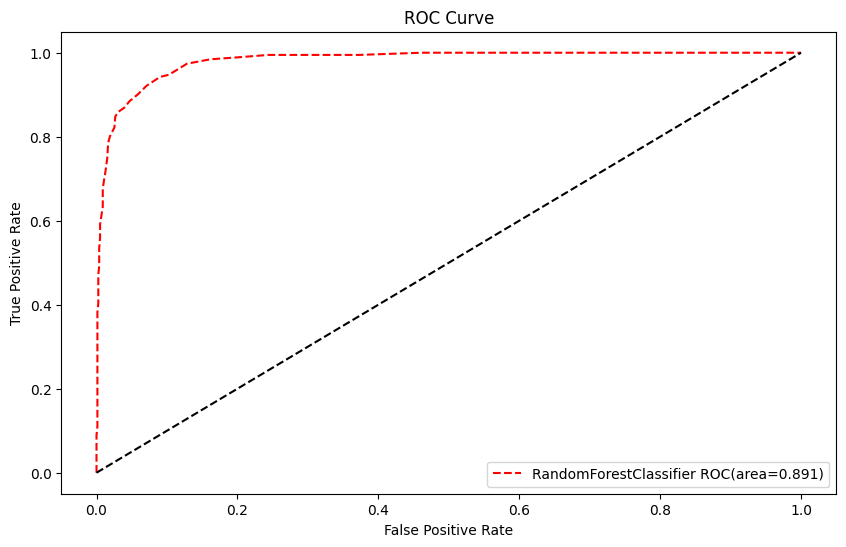

In [136]:
#Plot ROC AUC Curve
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

#Add the models to the list that you want to view on the ROC plot
auc_models=[
    {

    'label':'RandomForestClassifier',
    'color':'red',
    'linestyle':'--',
    'model':RandomForestClassifier(n_estimators=50, min_samples_split= 2, min_samples_leaf= 1, max_features='sqrt', max_depth=None),
    'x_test':x_test,
    'y_test':y_test,
    'x_train':x_train,
    'y_train':y_train,
    'ax':plt.gca(),
    'label':'RandomForestClassifier',
    'auc':0.891
    }
]

#create loop through all model
for algo in auc_models:
  model=algo['model']
  model.fit(x_train,y_train)
  #Compute false positive and true positive rate
  y_pred_proba=model.predict_proba(x_test)[:,1]
  fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)
  #Calculte area under the curve to disply on the plot
  plt.plot(fpr,tpr,label='%s ROC(area=%0.3f)' %(algo['label'],algo['auc']),color=algo['color'],linestyle=algo['linestyle'])
  plt.plot([0,1],[0,1],'k--')
  plt.xlim([0.0,1.0])
  plt.ylim([0.0,1.05])
  plt.axis('tight')
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')
  plt.legend(loc='lower right')
  plt.title('ROC Curve')
plt.show()